In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import os

sns.set_theme(style="whitegrid")

# 2. Ingestão e Limpeza de Dados
Carregamento do dataset do IMDb e remoção de valores nulos, mantendo os registros com zero votos para análise da Cauda Longa profunda.

In [2]:
df = pd.read_csv('../Imdb_Movie_Dataset.csv', engine='python', on_bad_lines='warn')

df.columns = [c.strip().lower() for c in df.columns]
col_votos = 'vote_count' if 'vote_count' in df.columns else [c for c in df.columns if 'vote' in c][0]

df = df.dropna(subset=[col_votos])
df_sorted = df.sort_values(by=col_votos, ascending=False).reset_index(drop=True)
df_sorted['Ranking'] = range(1, len(df_sorted) + 1)

# 3. Análise Estatística: Head/Tail Breaks
Cálculo da Média Aritmética Global para isolar a assimetria da distribuição e identificar o ponto de ruptura do mercado.

## Cálculo da Quantidade Total de Filmes e Média Global de Votos de Filme

Esta seção calcula a média global de votos (`media_global`) e o ponto de corte para segmentar os filmes em Mainstream e Cauda Longa, conforme detalhado na próxima célula.

In [3]:
media_global = df_sorted[col_votos].mean()
corte_index = len(df_sorted[df_sorted[col_votos] >= media_global])

print(f"Total de filmes: {len(df_sorted):,}")
print(f"Média Global: {media_global:.2f} votos")
print(f"Ponto de Corte (Ranking): {corte_index:,}")

Total de filmes: 951,555
Média Global: 22.51 votos
Ponto de Corte (Ranking): 46,038


## Limpeza do dataset antes da geração dos gráficos

O dataset já foi carregado e pré-processado na célula etapa 2, onde nulos foram removidos e a coluna de votos foi convertida para tipo numérico para garantir a consistência dos dados.

## 4. Análise de Viés Geográfico: Mainstream vs. Cauda Longa

Vamos investigar a origem geográfica dos filmes para entender se há um viés regional entre os filmes do Mainstream e da Cauda Longa.

## Gera os Gráficos de comparação entre Filmes Mainstream e Filmes Alternativos

A seguir, apresentamos o gráfico de viés geográfico, que compara a origem dos filmes entre os segmentos Mainstream e Cauda Longa, utilizando as definições de filmes Mainstream e Alternativos baseadas na média global de votos.

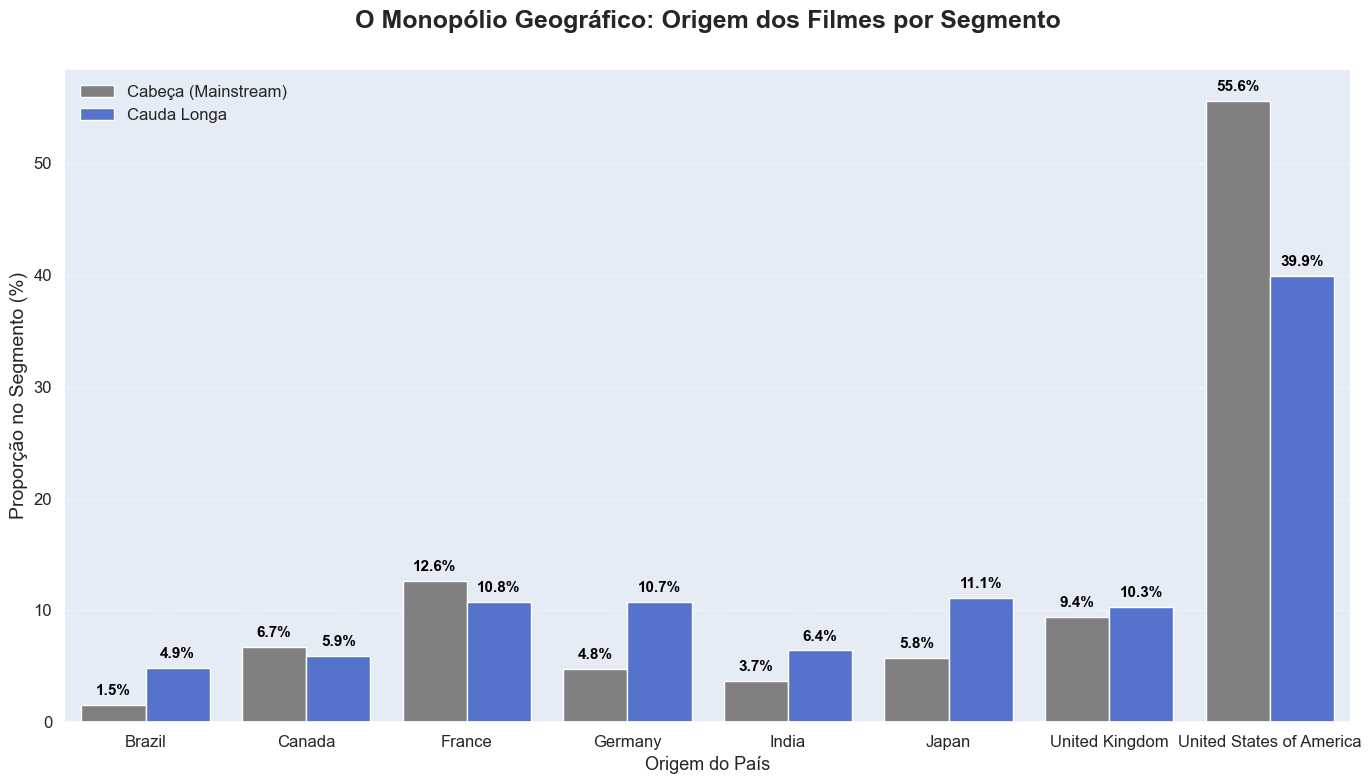

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_geo = df.copy()
df_geo[col_votos] = df_geo[col_votos].fillna(0)
df_geo['Segmento'] = df_geo[col_votos].apply(lambda x: 'Cabeça (Mainstream)' if x >= media_global else 'Cauda Longa')

def get_first_country(countries_str):
    if pd.isna(countries_str) or countries_str.strip() == '[]' or countries_str.strip() == '':
        return None
    try:
        countries_list = eval(countries_str)
        if isinstance(countries_list, list) and len(countries_list) > 0:
            if isinstance(countries_list[0], dict):
                return countries_list[0].get('iso_3166_1') or countries_list[0].get('name')
            else:
                return countries_list[0]
    except:
        if ',' in countries_str:
            return countries_str.split(',')[0].strip()
        return countries_str.strip()
    return None

df_geo['first_country'] = df_geo['production_countries'].apply(get_first_country)
df_geo = df_geo.dropna(subset=['first_country'])
top_8_countries = df_geo['first_country'].value_counts().head(8).index.tolist()
df_geo_filtered = df_geo[df_geo['first_country'].isin(top_8_countries)].copy()

segment_counts = df_geo_filtered['Segmento'].value_counts()
country_segment_counts = df_geo_filtered.groupby(['Segmento', 'first_country']).size().reset_index(name='count')

data_for_plot = []
for segment in segment_counts.index:
    total_in_segment = segment_counts[segment]
    segment_data = country_segment_counts[country_segment_counts['Segmento'] == segment].copy()
    segment_data['percentage'] = (segment_data['count'] / total_in_segment) * 100
    data_for_plot.append(segment_data)

df_plot = pd.concat(data_for_plot)

sns.set_theme(style='darkgrid') 

plt.figure(figsize=(14, 8), facecolor='white')

hue_order = ['Cabeça (Mainstream)', 'Cauda Longa']
palette_colors = {
    'Cabeça (Mainstream)': 'gray', 
    'Cauda Longa': 'royalblue'
}

ax = sns.barplot(
    data=df_plot, 
    x='first_country', 
    y='percentage', 
    hue='Segmento', 
    hue_order=hue_order,
    palette=palette_colors,
    edgecolor='white'
)

ax.set_facecolor('#E5ECF6')

plt.title('O Monopólio Geográfico: Origem dos Filmes por Segmento', 
          fontsize=18, fontweight='bold', pad=30, family='Arial')

plt.xlabel('Origem do País', fontsize=13) 
plt.ylabel('Proporção no Segmento (%)', fontsize=14, family='Arial')

ax.yaxis.grid(True, linestyle='--', which='major', color='white', alpha=0.5)
ax.xaxis.grid(False) 
sns.despine(left=True, bottom=False) 

plt.legend(title='', fontsize=12, frameon=False, loc='upper left')

plt.xticks(rotation=0, fontsize=12, family='Arial')
plt.yticks(fontsize=12, family='Arial')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()